# K-Nearest Neighbors (KNN) aplicado a un Agente de Pong

## ¿Qué es KNN?

**K-Nearest Neighbors (KNN)** es un algoritmo de aprendizaje supervisado simple pero poderoso. Su idea central es:

> *"Dime quiénes son tus vecinos y te diré quién eres"*

### Principio de funcionamiento

Para clasificar un nuevo punto de datos:
1. Calcula la **distancia** entre el nuevo punto y todos los puntos del conjunto de entrenamiento.
2. Selecciona los **K puntos más cercanos** (los K vecinos más próximos).
3. Realiza una **votación por mayoría**: la clase más frecuente entre los K vecinos es la predicción.

```
   ?  ←  Nuevo punto
   
   ○ ○       ← Vecinos clase A
     ?       ← ¿A cuál clase pertenece?
   △         ← Vecino clase B

   Con K=3: 2 votos clase A, 1 voto clase B → Predicción: Clase A
```

### Métricas de distancia comunes

| Métrica | Fórmula | Uso típico |
|---------|---------|------------|
| **Euclidiana** | √Σ(xᵢ - yᵢ)² | Datos continuos |
| **Manhattan** | Σ\|xᵢ - yᵢ\| | Datos en cuadrícula |
| **Minkowski** | (Σ\|xᵢ - yᵢ\|ᵖ)^(1/p) | Generalización |

### Ventajas y desventajas

✅ **Ventajas:**
- No requiere entrenamiento (lazy learner)
- Fácil de entender e implementar
- Funciona bien con datos no lineales

❌ **Desventajas:**
- Lento en predicción con datasets grandes
- Sensible a features irrelevantes
- Sensible a la escala de los datos

## 0. Instalación de dependencias

In [1]:
# Instalar dependencias necesarias
# !pip install numpy matplotlib scikit-learn

## 1. Implementación manual de KNN

Antes de usar la librería, veamos cómo funciona KNN desde cero:

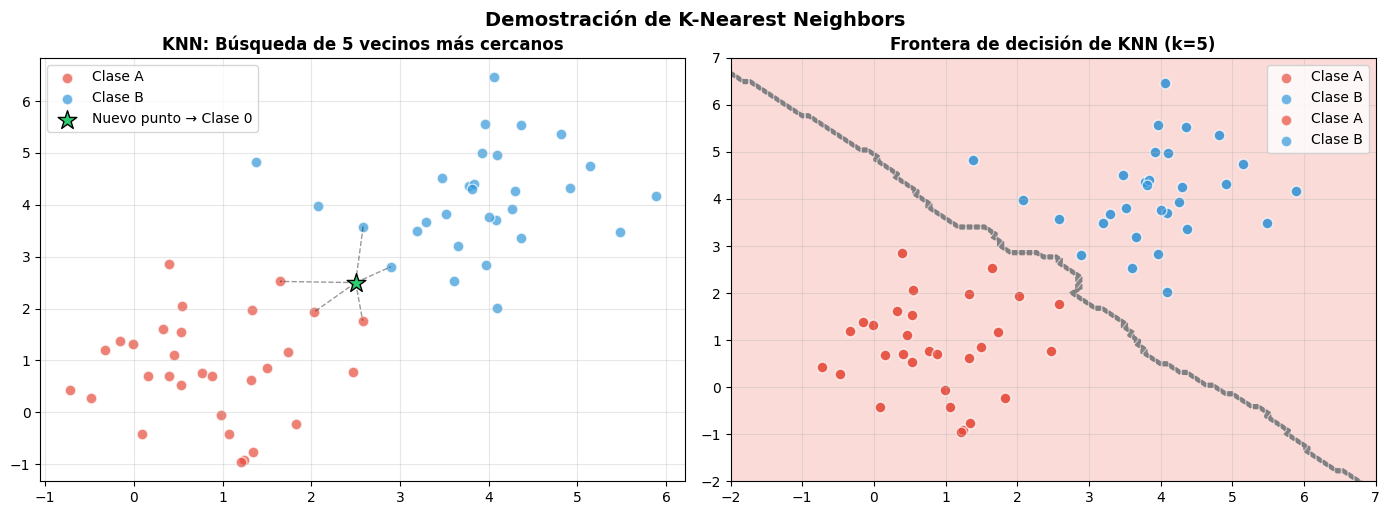

Predicción para el punto [2.5 2.5]: Clase 0 (A)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# KNN IMPLEMENTADO DESDE CERO
class KNNManual:
    """
    Implementación manual de K-Nearest Neighbors.

    Parámetros:
        k (int): Número de vecinos a considerar.
        metric (str): 'euclidean' o 'manhattan'.
    """
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Almacena los datos de entrenamiento (KNN no entrena realmente)."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _distancia(self, a, b):
        """Calcula la distancia entre dos puntos."""
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(a - b))

    def predict_one(self, x):
        """Predice la clase de un solo punto."""
        # Paso 1: Calcular distancias a todos los puntos de entrenamiento
        distancias = [self._distancia(np.array(x), punto) for punto in self.X_train]

        # Paso 2: Obtener los K índices más cercanos
        k_indices = np.argsort(distancias)[:self.k]

        # Paso 3: Obtener las etiquetas de los K vecinos
        k_etiquetas = [self.y_train[i] for i in k_indices]

        # Paso 4: Votación por mayoría
        voto_mayoritario = Counter(k_etiquetas).most_common(1)[0][0]
        return voto_mayoritario

    def predict(self, X):
        """Predice la clase para múltiples puntos."""
        return np.array([self.predict_one(x) for x in X])


# DEMOSTRACIÓN VISUAL CON DATOS SINTÉTICOS
np.random.seed(42)

# Generar dos clases de datos
clase_A = np.random.randn(30, 2) + [1, 1]
clase_B = np.random.randn(30, 2) + [4, 4]

X_demo = np.vstack([clase_A, clase_B])
y_demo = np.array([0]*30 + [1]*30)

# Nuevo punto a clasificar
nuevo_punto = np.array([2.5, 2.5])

# Entrenar KNN manual
knn_manual = KNNManual(k=5)
knn_manual.fit(X_demo, y_demo)
pred = knn_manual.predict_one(nuevo_punto)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#e74c3c', '#3498db']
etiquetas = ['Clase A', 'Clase B']

for ax in axes:
    for clase, color, etiqueta in zip([0, 1], colores, etiquetas):
        mask = y_demo == clase
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
                   c=color, label=etiqueta, alpha=0.7, s=60, edgecolors='white')

# Gráfico izquierdo: mostrar el proceso de K vecinos
distancias = [knn_manual._distancia(nuevo_punto, p) for p in X_demo]
k_idx = np.argsort(distancias)[:5]

for idx in k_idx:
    axes[0].plot([nuevo_punto[0], X_demo[idx, 0]],
                 [nuevo_punto[1], X_demo[idx, 1]],
                 'k--', alpha=0.4, linewidth=1)

axes[0].scatter(*nuevo_punto, c='#2ecc71', s=200, zorder=5,
                marker='*', label=f'Nuevo punto → Clase {pred}', edgecolors='black')
axes[0].set_title('KNN: Búsqueda de 5 vecinos más cercanos', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico derecho: frontera de decisión
xx, yy = np.meshgrid(np.linspace(-2, 7, 100), np.linspace(-2, 7, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn_manual.predict(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.2, colors=['#e74c3c', '#3498db'])
axes[1].contour(xx, yy, Z, colors='gray', linewidths=1, linestyles='--')
for clase, color, etiqueta in zip([0, 1], colores, etiquetas):
    mask = y_demo == clase
    axes[1].scatter(X_demo[mask, 0], X_demo[mask, 1],
                    c=color, label=etiqueta, alpha=0.7, s=60, edgecolors='white')
axes[1].set_title('Frontera de decisión de KNN (k=5)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Demostración de K-Nearest Neighbors', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('knn_demo.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Predicción para el punto {nuevo_punto}: Clase {pred} ({"A" if pred==0 else "B"})')

## 2. Efecto del valor de K

El parámetro **K** es crítico: valores pequeños generan fronteras muy complejas (sobreajuste), valores grandes las suavizan (subajuste).

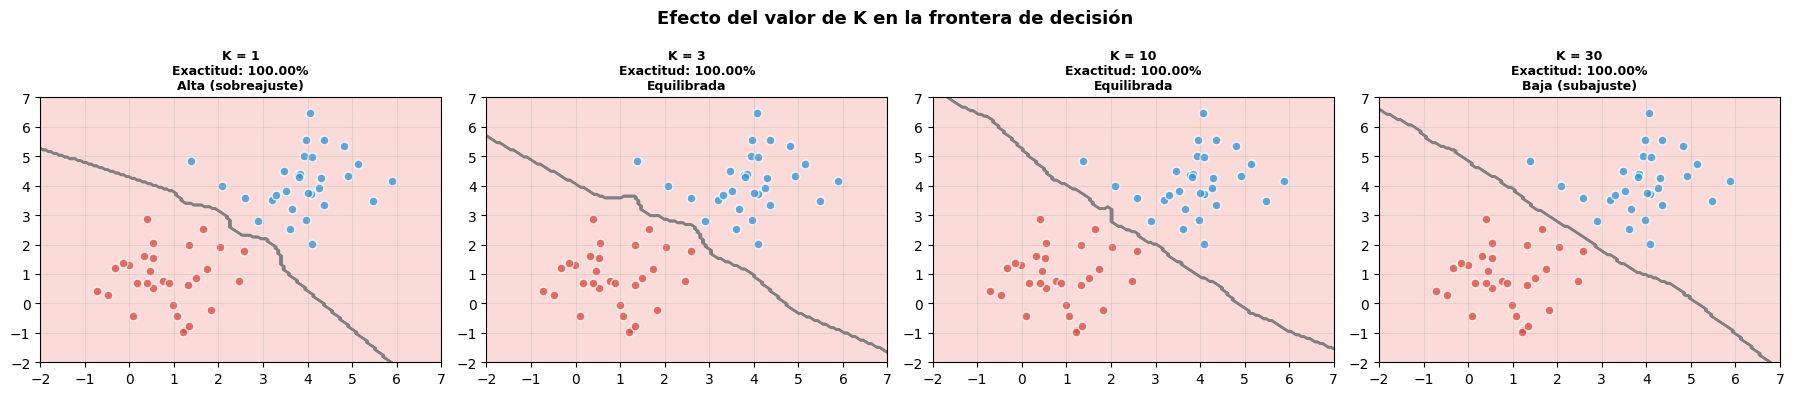

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Efecto del valor de K en la frontera de decisión
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
valores_k = [1, 3, 10, 30]

for ax, k in zip(axes, valores_k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_demo, y_demo)

    xx, yy = np.meshgrid(np.linspace(-2, 7, 150), np.linspace(-2, 7, 150))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, colors=['#e74c3c', '#3498db'])
    ax.contour(xx, yy, Z, colors='gray', linewidths=1)

    for clase, color in zip([0, 1], ['#e74c3c', '#3498db']):
        mask = y_demo == clase
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1], c=color, alpha=0.8, s=40, edgecolors='white')

    score = accuracy_score(y_demo, knn.predict(X_demo))
    complejidad = 'Alta (sobreajuste)' if k <= 2 else ('Baja (subajuste)' if k >= 20 else 'Equilibrada')
    ax.set_title(f'K = {k}\nExactitud: {score:.2%}\n{complejidad}', fontsize=9, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Efecto del valor de K en la frontera de decisión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('efecto_k.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Clases del entorno y agente Pong

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from math import ceil, floor
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# ENTORNO DE PONG
class PongEnvironment:
    def __init__(self, max_life=3, height_px=40, width_px=50, movimiento_px=3):
        self.action_space = ['Arriba', 'Abajo']
        self._step_penalization = 0
        self.state = [0, 0, 0]
        self.total_reward = 0
        self.dx = movimiento_px
        self.dy = movimiento_px
        filas = ceil(height_px / movimiento_px)
        columnas = ceil(width_px / movimiento_px)
        self.positions_space = np.array([[[0 for z in range(columnas)] for y in range(filas)] for x in range(filas)])
        self.lives = max_life
        self.max_life = max_life
        self.x = randint(int(width_px / 2), width_px)
        self.y = randint(0, height_px - 10)
        self.player_alto = int(height_px / 4)
        self.player1 = self.player_alto
        self.score = 0
        self.width_px = width_px
        self.height_px = height_px
        self.radio = 2.5

    def reset(self):
        self.total_reward = 0
        self.state = [0, 0, 0]
        self.lives = self.max_life
        self.score = 0
        self.x = randint(int(self.width_px / 2), self.width_px)
        self.y = randint(0, self.height_px - 10)
        return self.state

    def step(self, action, animate=False):
        self._apply_action(action, animate)
        done = self.lives <= 0
        reward = self.score + self._step_penalization
        self.total_reward += reward
        return self.state, reward, done

    def _apply_action(self, action, animate=False):
        if action == "Arriba":
            self.player1 += abs(self.dy)
        elif action == "Abajo":
            self.player1 -= abs(self.dy)
        self.avanza_player()
        self.avanza_frame()
        self.state = (floor(self.player1 / abs(self.dy)) - 2,
                      floor(self.y / abs(self.dy)) - 2,
                      floor(self.x / abs(self.dx)) - 2)

    def detectaColision(self, ball_y, player_y):
        return (player_y + self.player_alto >= (ball_y - self.radio)) and (player_y <= (ball_y + self.radio))

    def avanza_player(self):
        if self.player1 + self.player_alto >= self.height_px:
            self.player1 = self.height_px - self.player_alto
        elif self.player1 <= -abs(self.dy):
            self.player1 = -abs(self.dy)

    def avanza_frame(self):
        self.x += self.dx
        self.y += self.dy
        if self.x <= 3 or self.x > self.width_px:
            self.dx = -self.dx
            if self.x <= 3:
                ret = self.detectaColision(self.y, self.player1)
                if ret:
                    self.score = 10
                else:
                    self.score = -10
                    self.lives -= 1
                    if self.lives > 0:
                        self.x = randint(int(self.width_px / 2), self.width_px)
                        self.y = randint(0, self.height_px - 10)
                        self.dx = abs(self.dx)
                        self.dy = abs(self.dy)
        else:
            self.score = 0
        if self.y < 0 or self.y > self.height_px:
            self.dy = -self.dy


# AGENTE Q-LEARNING
class PongAgent:
    def __init__(self, game, policy=None, discount_factor=0.1, learning_rate=0.1, ratio_explotacion=0.9):
        if policy is not None:
            self._q_table = policy
        else:
            position = list(game.positions_space.shape)
            position.append(len(game.action_space))
            self._q_table = np.zeros(position)
        self.discount_factor = discount_factor
        self.learning_rate = learning_rate
        self.ratio_explotacion = ratio_explotacion

    def get_next_step(self, state, game):
        next_step = np.random.choice(list(game.action_space))
        if np.random.uniform() <= self.ratio_explotacion:
            idx_action = np.random.choice(np.flatnonzero(
                self._q_table[state[0], state[1], state[2]] ==
                self._q_table[state[0], state[1], state[2]].max()
            ))
            next_step = list(game.action_space)[idx_action]
        return next_step

    def update(self, game, old_state, action_taken, reward_action_taken, new_state, reached_end):
        idx_action_taken = list(game.action_space).index(action_taken)
        actual_q_value = self._q_table[old_state[0], old_state[1], old_state[2], idx_action_taken]
        future_q_value_options = self._q_table[new_state[0], new_state[1], new_state[2]]
        future_max_q_value = reward_action_taken + self.discount_factor * future_q_value_options.max()
        if reached_end:
            future_max_q_value = reward_action_taken
        self._q_table[old_state[0], old_state[1], old_state[2], idx_action_taken] = actual_q_value + \
            self.learning_rate * (future_max_q_value - actual_q_value)

    def get_policy(self):
        return self._q_table

## 4. Entrenamiento con Q-Learning y extracción de política

Primero entrenamos el agente con Q-Learning para generar una política óptima. Luego usaremos **KNN para aprender esa política**.

## ¿Qué es Q-Learning?

**Q-Learning** es un algoritmo de **aprendizaje por refuerzo (Reinforcement Learning - RL)** que permite a un agente aprender una política óptima de acciones a tomar en un entorno dado, con el objetivo de maximizar una recompensa acumulada. Es un algoritmo **off-policy**, lo que significa que aprende de acciones que no necesariamente son las que el agente está tomando actualmente.

### Principio de Funcionamiento

El corazón de Q-Learning es la **Q-table** (tabla Q), que es una tabla donde cada entrada `Q(estado, acción)` almacena el valor esperado de tomar una acción específica en un estado dado, y luego seguir la política óptima a partir de ese momento.

El algoritmo funciona iterativamente, actualizando los valores Q basándose en la ecuación de Bellman:

`Q(s, a) ← Q(s, a) + α [r + γ maxₐ' Q(s', a') - Q(s, a)]`

Donde:
- `s`: estado actual
- `a`: acción tomada
- `r`: recompensa recibida tras tomar `a` en `s`
- `s'`: nuevo estado
- `a'`: posibles acciones en el nuevo estado
- `α` (alpha): tasa de aprendizaje (learning rate), controla cuánto se modifican los valores Q en cada paso (0 < α ≤ 1).
- `γ` (gamma): factor de descuento (discount factor), prioriza recompensas futuras (0 ≤ γ ≤ 1).
- `maxₐ' Q(s', a')`: el valor Q máximo esperado en el nuevo estado `s'`

### Pasos Básicos
1.  **Inicialización**: La Q-table se inicializa con valores arbitrarios (a menudo ceros).
2.  **Exploración y Explotación**: En cada paso, el agente elige una acción `a` para el estado actual `s`. Puede elegir una acción aleatoria (exploración) para descubrir nuevas rutas, o la acción con el valor Q más alto (explotación) para aprovechar lo aprendido. Esto a menudo se maneja con una estrategia ε-greedy.
3.  **Ejecución y Observación**: El agente ejecuta la acción `a`, observa la recompensa `r` y el nuevo estado `s'`.
4.  **Actualización de la Q-table**: Se actualiza el valor `Q(s, a)` usando la ecuación de Bellman.
5.  **Repetición**: El proceso se repite hasta que el agente alcanza un estado terminal o se completa un número predefinido de episodios.

### Ventajas y Desventajas

✅ **Ventajas:**
-   No requiere un modelo del entorno.
-   Puede aprender políticas óptimas incluso con datos de acciones subóptimas.
-   Relativamente simple de implementar para problemas con espacios de estados y acciones discretos y pequeños.

❌ **Desventajas:**
-   No escala bien a entornos con grandes espacios de estados y acciones (problema de la dimensionalidad).
-   Puede ser lento para converger en entornos complejos.
-   Sensible a los hiperparámetros (α, γ, ε).

🎮 Entrenando agente con Q-Learning (3000 rondas)...
✅ Entrenamiento completado


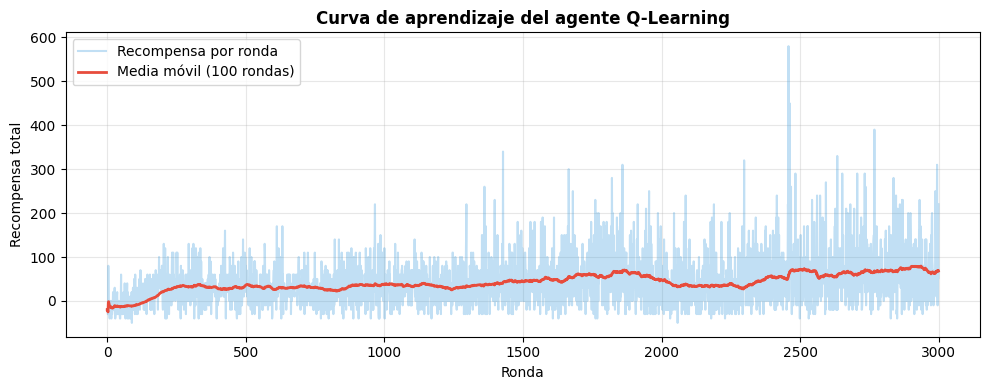

In [24]:
def play(rounds=5000, max_life=3, discount_factor=0.1, learning_rate=0.1,
         ratio_explotacion=0.9, learner=None, game=None):
    if game is None:
        game = PongEnvironment(max_life=max_life, movimiento_px=3)
    if learner is None:
        learner = PongAgent(game, discount_factor=discount_factor,
                            learning_rate=learning_rate,
                            ratio_explotacion=ratio_explotacion)
    rewards_por_ronda = []
    for ronda in range(rounds):
        state = game.reset()
        done = False
        while not done and game.total_reward <= 1000:
            old_state = np.array(state)
            next_action = learner.get_next_step(state, game)
            state, reward, done = game.step(next_action)
            learner.update(game, old_state, next_action, reward, state, done)
        rewards_por_ronda.append(game.total_reward)
    return learner, game, rewards_por_ronda


print("🎮 Entrenando agente con Q-Learning (3000 rondas)...")
learner, game, rewards_hist = play(rounds=3000, discount_factor=0.1,
                                   learning_rate=0.1, ratio_explotacion=0.9)
print("✅ Entrenamiento completado")

# Visualizar curva de aprendizaje
ventana = 100
media_movil = [np.mean(rewards_hist[max(0, i-ventana):i+1]) for i in range(len(rewards_hist))]

plt.figure(figsize=(10, 4))
plt.plot(rewards_hist, alpha=0.3, color='#3498db', label='Recompensa por ronda')
plt.plot(media_movil, color='#e74c3c', linewidth=2, label=f'Media móvil ({ventana} rondas)')
plt.xlabel('Ronda')
plt.ylabel('Recompensa total')
plt.title('Curva de aprendizaje del agente Q-Learning', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_aprendizaje.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Convertir la Q-table en un dataset para KNN

La idea clave: extraemos la **política óptima** de la Q-table (qué acción tomar en cada estado) y la usamos como dataset etiquetado para entrenar KNN.

Dimensiones de la Q-table: (14, 14, 17, 2)
  - Posición del jugador: 14 estados
  - Posición Y de la pelota: 14 estados
  - Posición X de la pelota: 17 estados
  - Acciones disponibles: 2 (['Arriba', 'Abajo'])

Distribución del dataset:
  Acción 'Arriba' (clase 0): 1875 muestras (56.3%)
  Acción 'Abajo' (clase 1): 1457 muestras (43.7%)
  Total: 3332 muestras


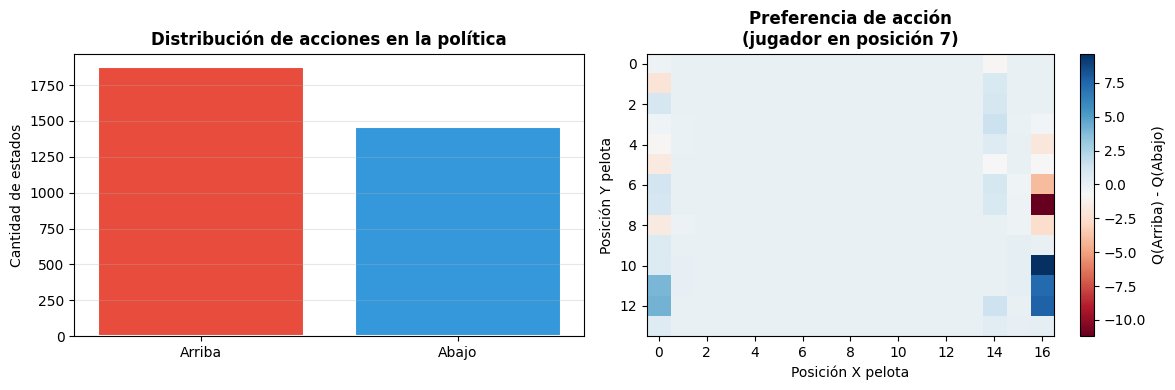

In [25]:
# EXTRACCIÓN DE LA POLÍTICA DESDE LA Q-TABLE
q_table = learner.get_policy()
pos_n, y_n, x_n, n_actions = q_table.shape

print(f"Dimensiones de la Q-table: {q_table.shape}")
print(f"  - Posición del jugador: {pos_n} estados")
print(f"  - Posición Y de la pelota: {y_n} estados")
print(f"  - Posición X de la pelota: {x_n} estados")
print(f"  - Acciones disponibles: {n_actions} ({game.action_space})")

# Construir dataset: X = estados, y = mejor acción según Q-table
X, y = [], []
for i in range(pos_n):
    for j in range(y_n):
        for k in range(x_n):
            mejor_accion = int(np.argmax(q_table[i, j, k]))
            X.append([i, j, k])
            y.append(mejor_accion)

X = np.array(X)
y = np.array(y)

# Distribución de clases
clases, conteos = np.unique(y, return_counts=True)
print(f"\nDistribución del dataset:")
for c, cnt in zip(clases, conteos):
    accion = game.action_space[c]
    print(f"  Acción '{accion}' (clase {c}): {cnt} muestras ({cnt/len(y)*100:.1f}%)")
print(f"  Total: {len(X)} muestras")

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([game.action_space[c] for c in clases], conteos,
            color=['#e74c3c', '#3498db'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de acciones en la política', fontweight='bold')
axes[0].set_ylabel('Cantidad de estados')
axes[0].grid(axis='y', alpha=0.3)

# Visualizar un slice de la Q-table (posición del jugador fija)
slice_q = q_table[pos_n // 2, :, :, 0] - q_table[pos_n // 2, :, :, 1]
im = axes[1].imshow(slice_q, cmap='RdBu', aspect='auto')
plt.colorbar(im, ax=axes[1], label='Q(Arriba) - Q(Abajo)')
axes[1].set_title(f'Preferencia de acción\n(jugador en posición {pos_n//2})', fontweight='bold')
axes[1].set_xlabel('Posición X pelota')
axes[1].set_ylabel('Posición Y pelota')

plt.tight_layout()
plt.savefig('distribucion_politica.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Entrenamiento y evaluación del modelo KNN

Tamaño entrenamiento: 2665 | Validación: 667

  EXACTITUD KNN: 0.6732 (67.32%)

Reporte de clasificación:
              precision    recall  f1-score   support

      Arriba       0.71      0.70      0.71       375
       Abajo       0.62      0.64      0.63       292

    accuracy                           0.67       667
   macro avg       0.67      0.67      0.67       667
weighted avg       0.67      0.67      0.67       667



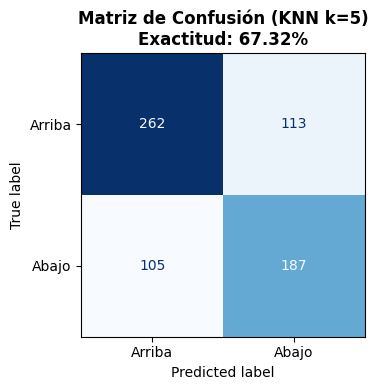

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# División train/test
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Tamaño entrenamiento: {len(X_train)} | Validación: {len(X_val)}")

# Entrenar KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluar
y_pred = knn.predict(X_val)
exactitud = accuracy_score(y_val, y_pred)

print(f"\n{'='*40}")
print(f"  EXACTITUD KNN: {exactitud:.4f} ({exactitud*100:.2f}%)")
print(f"{'='*40}\n")
print("Reporte de clasificación:")
print(classification_report(y_val, y_pred,
                             target_names=game.action_space))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=game.action_space)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión (KNN k=5)\nExactitud: {exactitud:.2%}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Búsqueda del K óptimo

Usamos **validación cruzada** para encontrar el mejor valor de K.

Mejor K (validación cruzada): 19 con exactitud 0.6972


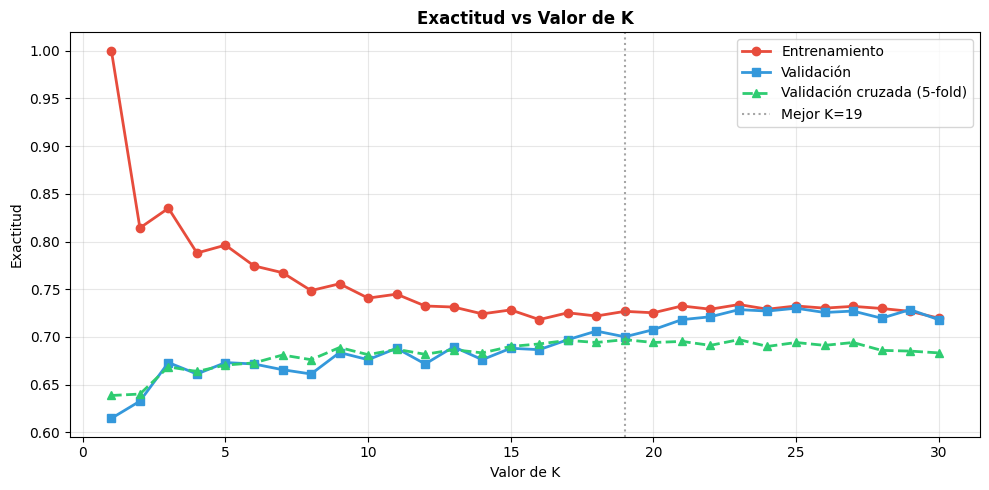

In [28]:
from sklearn.model_selection import cross_val_score

# Probar diferentes valores de K
k_values = list(range(1, 31))
scores_train = []
scores_val = []
scores_cv = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    scores_train.append(accuracy_score(y_train, knn_k.predict(X_train)))
    scores_val.append(accuracy_score(y_val, knn_k.predict(X_val)))
    cv = cross_val_score(knn_k, X_train, y_train, cv=5, scoring='accuracy')
    scores_cv.append(cv.mean())

# Mejor K
mejor_k = k_values[np.argmax(scores_cv)]
print(f"Mejor K (validación cruzada): {mejor_k} con exactitud {max(scores_cv):.4f}")

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_train, 'o-', color='#e74c3c', label='Entrenamiento', linewidth=2)
plt.plot(k_values, scores_val, 's-', color='#3498db', label='Validación', linewidth=2)
plt.plot(k_values, scores_cv, '^--', color='#2ecc71', label='Validación cruzada (5-fold)', linewidth=2)
plt.axvline(x=mejor_k, color='gray', linestyle=':', alpha=0.7, label=f'Mejor K={mejor_k}')
plt.xlabel('Valor de K')
plt.ylabel('Exactitud')
plt.title('Exactitud vs Valor de K', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('k_optimo.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Agente KNN jugando Pong

Ahora usamos el modelo KNN como política del agente y comparamos su rendimiento contra el agente original.

In [29]:
# AGENTE BASADO EN KNN
class KNNPongAgent:
    """
    Agente que usa KNN en lugar de Q-table para decidir acciones.

    Diferencia clave con Q-Learning:
    - Q-Learning: busca en una tabla de valores exactos.
    - KNN: generaliza por similitud de estados vecinos.
    """
    def __init__(self, knn_model, action_space):
        self.knn = knn_model
        self.action_space = action_space

    def get_next_step(self, state, game=None):
        estado = np.array(state).reshape(1, -1)
        idx_accion = self.knn.predict(estado)[0]
        return self.action_space[idx_accion]


def evaluar_agente(agente, n_episodios=200, max_life=3):
    """Evalúa un agente jugando N episodios y retorna métricas."""
    recompensas = []
    colisiones_exitosas = []

    for _ in range(n_episodios):
        env = PongEnvironment(max_life=max_life, movimiento_px=3)
        state = env.reset()
        done = False
        golpes = 0
        while not done and env.total_reward <= 1000:
            accion = agente.get_next_step(state, env)
            state, reward, done = env.step(accion)
            if reward == 10:
                golpes += 1
        recompensas.append(env.total_reward)
        colisiones_exitosas.append(golpes)

    return {
        'recompensa_media': np.mean(recompensas),
        'recompensa_std': np.std(recompensas),
        'golpes_medios': np.mean(colisiones_exitosas),
        'recompensas': recompensas
    }


# Entrenar KNN con el mejor K encontrado
knn_optimo = KNeighborsClassifier(n_neighbors=mejor_k)
knn_optimo.fit(X_train, y_train)

# Crear agente KNN
agente_knn = KNNPongAgent(knn_optimo, game.action_space)

# Agente Q-Learning para comparar
class AgentQLearning:
    def __init__(self, learner_orig):
        self.learner = learner_orig
    def get_next_step(self, state, game):
        return self.learner.get_next_step(state, game)

agente_q = AgentQLearning(learner)

print("Evaluando agentes (200 episodios cada uno)...")
metricas_knn = evaluar_agente(agente_knn)
metricas_q = evaluar_agente(agente_q)

print(f"\n{'Métrica':<25} {'Q-Learning':>15} {'KNN':>15}")
print("-" * 55)
print(f"{'Recompensa media':<25} {metricas_q['recompensa_media']:>15.2f} {metricas_knn['recompensa_media']:>15.2f}")
print(f"{'Desv. estándar':<25} {metricas_q['recompensa_std']:>15.2f} {metricas_knn['recompensa_std']:>15.2f}")
print(f"{'Golpes medios/episodio':<25} {metricas_q['golpes_medios']:>15.2f} {metricas_knn['golpes_medios']:>15.2f}")

Evaluando agentes (200 episodios cada uno)...

Métrica                        Q-Learning             KNN
-------------------------------------------------------
Recompensa media                    89.50          200.80
Desv. estándar                      88.34          318.85
Golpes medios/episodio              12.09           23.05


## 9. Comparación visual de rendimiento

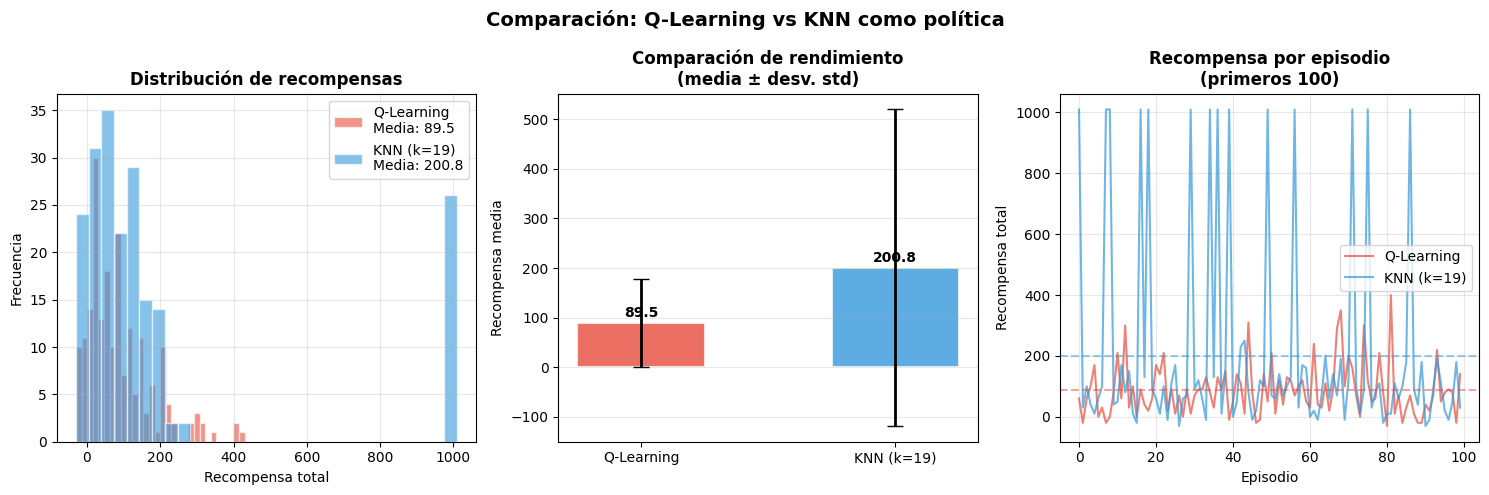

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma de recompensas
axes[0].hist(metricas_q['recompensas'], bins=30, alpha=0.6, color='#e74c3c',
             label=f'Q-Learning\nMedia: {metricas_q["recompensa_media"]:.1f}', edgecolor='white')
axes[0].hist(metricas_knn['recompensas'], bins=30, alpha=0.6, color='#3498db',
             label=f'KNN (k={mejor_k})\nMedia: {metricas_knn["recompensa_media"]:.1f}', edgecolor='white')
axes[0].set_xlabel('Recompensa total')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de recompensas', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Comparación de medias con barras de error
nombres = ['Q-Learning', f'KNN (k={mejor_k})']
medias = [metricas_q['recompensa_media'], metricas_knn['recompensa_media']]
stds = [metricas_q['recompensa_std'], metricas_knn['recompensa_std']]
colores_bar = ['#e74c3c', '#3498db']

bars = axes[1].bar(nombres, medias, color=colores_bar, alpha=0.8,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[1].errorbar(nombres, medias, yerr=stds, fmt='none',
                 color='black', capsize=6, linewidth=2)
for bar, media in zip(bars, medias):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{media:.1f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Recompensa media')
axes[1].set_title('Comparación de rendimiento\n(media ± desv. std)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Evolución de recompensas por episodio (primeros 100)
n_mostrar = 100
axes[2].plot(metricas_q['recompensas'][:n_mostrar], alpha=0.7,
             color='#e74c3c', label='Q-Learning', linewidth=1.5)
axes[2].plot(metricas_knn['recompensas'][:n_mostrar], alpha=0.7,
             color='#3498db', label=f'KNN (k={mejor_k})', linewidth=1.5)
axes[2].axhline(y=metricas_q['recompensa_media'], color='#e74c3c',
                linestyle='--', alpha=0.5)
axes[2].axhline(y=metricas_knn['recompensa_media'], color='#3498db',
                linestyle='--', alpha=0.5)
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('Recompensa total')
axes[2].set_title(f'Recompensa por episodio\n(primeros {n_mostrar})', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Comparación: Q-Learning vs KNN como política', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_rendimiento.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Comparación con diferentes métricas de distancia

Sin normalización:
  euclidean      : 0.7001
  manhattan      : 0.7076
  chebyshev      : 0.7106

Con normalización (StandardScaler):
  euclidean      : 0.7031
  manhattan      : 0.7106
  chebyshev      : 0.6792


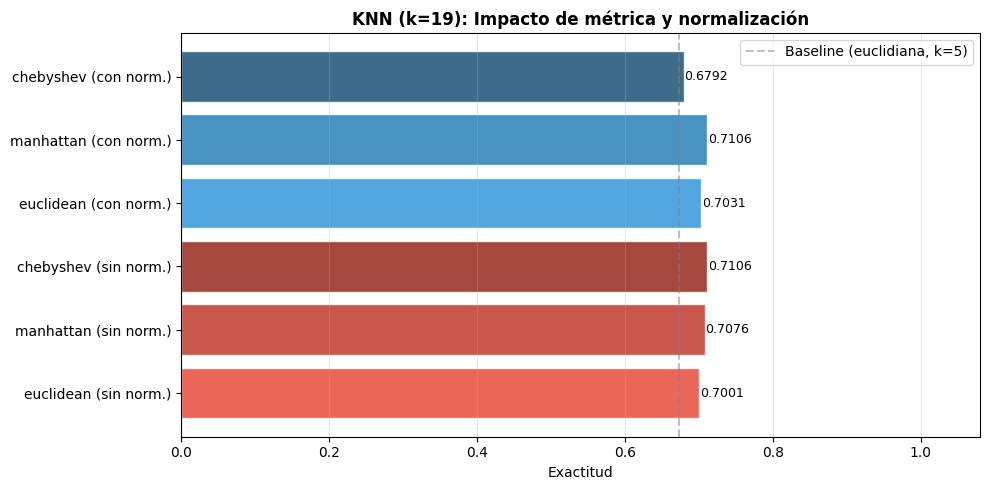

In [31]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# COMPARACIÓN: Euclidiana vs Manhattan vs Chebyshev
# + Efecto de la normalización
# ============================================================
metricas_dist = ['euclidean', 'manhattan', 'chebyshev']
resultados = {}

# Sin normalización
print("Sin normalización:")
for metrica in metricas_dist:
    knn_m = KNeighborsClassifier(n_neighbors=mejor_k, metric=metrica)
    knn_m.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn_m.predict(X_val))
    resultados[f'{metrica} (sin norm.)'] = acc
    print(f"  {metrica:15s}: {acc:.4f}")

# Con normalización
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)

print("\nCon normalización (StandardScaler):")
for metrica in metricas_dist:
    knn_m = KNeighborsClassifier(n_neighbors=mejor_k, metric=metrica)
    knn_m.fit(X_train_norm, y_train)
    acc = accuracy_score(y_val, knn_m.predict(X_val_norm))
    resultados[f'{metrica} (con norm.)'] = acc
    print(f"  {metrica:15s}: {acc:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
nombres_r = list(resultados.keys())
valores_r = list(resultados.values())
colores_r = ['#e74c3c', '#c0392b', '#96281b'] * 2
colores_r[3:] = ['#3498db', '#2980b9', '#1a5276']

bars = ax.barh(nombres_r, valores_r, color=colores_r, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, valores_r):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Exactitud')
ax.set_title(f'KNN (k={mejor_k}): Impacto de métrica y normalización', fontweight='bold')
ax.set_xlim(0, 1.08)
ax.axvline(x=accuracy_score(y_val, knn.predict(X_val)), color='gray',
           linestyle='--', alpha=0.5, label='Baseline (euclidiana, k=5)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('metricas_distancia.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

def animate_pong_game(agente, env, frames_per_second=15):
    """Anima un episodio del juego de Pong con el agente dado.

    Esta versión muestra solo una pelota coloreada y en movimiento
    para mejorar la visibilidad de su trayectoria.
    """
    print("Iniciando animación del agente KNN (pelota visible y en movimiento)...")
    state = env.reset()
    done = False
    fig, ax = plt.subplots(figsize=(6, 8))
    plt.ion() # Activar modo interactivo para matplotlib

    current_action_display = "N/A"

    while not done and env.total_reward <= 1000:
        clear_output(wait=True)
        ax.clear()

        # Dibujar el "campo" de juego
        ax.set_xlim(0, env.width_px)
        ax.set_ylim(0, env.height_px)
        ax.set_aspect('equal')
        ax.set_facecolor('black')

        # Dibujar la pelota actual de forma distintiva (sin rastro)
        ball_circle = plt.Circle((env.x, env.y), env.radio, color='lime', alpha=1.0, zorder=6) # Color brillante, opaca, zorder alto
        ax.add_patch(ball_circle)

        # Dibujar el paddle del jugador (pared izquierda)
        ax.add_patch(plt.Rectangle((0, env.player1), 2, env.player_alto, color='blue', zorder=5))

        # Dibujar la pared derecha (donde la pelota 'sale')
        ax.add_patch(plt.Rectangle((env.width_px - 2, 0), 2, env.height_px, color='gray', alpha=0.5, zorder=1))

        # Mostrar la acción del agente y otros datos
        ax.text(env.width_px * 0.5, env.height_px * 0.95,
                f'Acción: {current_action_display}',
                color='cyan', fontsize=12, ha='center', va='top')
        ax.set_title(f'Pong Animado - Vidas: {env.lives}, Score: {env.total_reward}', color='white', fontweight='bold')
        ax.axis('off') # Ocultar ejes

        plt.show()
        plt.pause(1 / frames_per_second)

        # El agente decide y toma una acción
        action = agente.get_next_step(state, env)
        current_action_display = action # Guardar para mostrar en el siguiente frame
        state, reward, done = env.step(action)

    clear_output(wait=True)
    plt.close(fig) # Cerrar la figura al finalizar
    print(f"Animación terminada. Score final: {env.total_reward}, Vidas restantes: {env.lives}")


# Ejecutar la animación con el agente KNN
anim_env = PongEnvironment(max_life=3, movimiento_px=3)

animate_pong_game(agente_knn, anim_env, frames_per_second=20)

Animación terminada. Score final: 110, Vidas restantes: 0


## 11. Conclusiones

### ¿Qué aprendimos?

| Aspecto | Q-Learning | KNN |
|---------|-----------|-----|
| **Tipo** | Aprendizaje por refuerzo | Aprendizaje supervisado |
| **Entrenamiento** | Exploratorio (prueba/error) | A partir de ejemplos etiquetados |
| **Memoria** | Q-table (tabla de estados) | Guarda todos los ejemplos de entrenamiento |
| **Generalización** | Limitada a estados visitados | Por similitud de estados vecinos |
| **Velocidad predicción** | O(1) - búsqueda en tabla | O(n) - cálculo de distancias |

### Conclusiones

1. **KNN como imitador de política**: KNN aprendió a imitar la política óptima del agente Q-Learning con alta exactitud, lo cual demuestra que la política tiene estructura aprendible.

2. **Efecto de K**: Valores pequeños de K (k=1) memorizan perfectamente el entrenamiento pero pueden ser frágiles. Valores más grandes suavizan la frontera de decisión.

3. **Métrica de distancia**: En este espacio de estados (posiciones discretas), la distancia Euclidiana y Manhattan funcionan de manera similar dado que los features tienen la misma escala.

4. **Limitación de KNN**: A diferencia de Q-Learning, KNN no puede mejorar su política con experiencia nueva; es estático una vez entrenado.